# Projeto – Academia Model Fitness

## 1 - Importando Bibliotecas.

In [3]:
import pandas as pd
import numpy as np               
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns            
from scipy import stats
from IPython.display import display
import textwrap
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage

## 2 - Carregando Dados.

### 2.1 - Importando dataframes.

In [4]:
df = pd.read_csv('../data/gym_churn_us.csv')

### 2.2 - Descrição dos Dados.


Churn — a rotatividade do mês em questão  

Dados do mês anterior:  

gender -  genero.  
Near_Location — se o cliente morar ou trabalhar na vizinhança onde a academia está localizada.  
Partner — se o usuário for um funcionário de uma companhia parceira (a academia tem empresas parceiras cujos funcionários conseguem descontos; nesses casos, a academia armazena informações sobre clientes de são funcionários).  
Promo_friends — se o cliente originalmente se inscreveu através de uma oferta "traga um amigo" eles normalmente usam o código de promoção do amigo quando pagam pela primeira filiação).  
Phone — se o usuário fornece o seu número de telefone.  
age - (idade).  
Lifetime — o tempo (em meses) desde a primeira vez que o cliente veio à academia.  


Dados do log de frequência e compras e dados sobre status de filiação atual:

Contract_period — 1 mês, 3 meses, 6 meses, ou um ano.  
Month_to_end_contract — os meses remanescentes até que o contrato expira.  
Group_visits — se o cliente participa de sessões em grupo.  
Avg_class_frequency_total — frequência média de idas por semana por toda a vida do cliente.  
Avg_class_frequency_current_month — frequência média de visitas por semana durante o mês corrente.  
Avg_additional_charges_total — a quantidade total de dinheiro gasto em outros serviços da academia: café, artigos esportivos, cosméticos, massagem, etc.

Para algumas colunas teremos o valores 0 e 1, onde 1 é sim e 0 é não.  
A coluna gender (genero), possui valores como 0 e 1, que não foram trazidos como qual genero é cada valor, nesse caso vamos desonsiderar a variavel gender para os calculos.

## 3 - Análise exploratória dos dados (AED).

### 3.1 - Imprimindo dataframe, exibindo informações e verificando valores nulos.

In [5]:
print(df.shape)
display(df.head())
df.info()

(4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [6]:
df.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

O conjunto de dados não apresenta valores ausentes.

### 3.2 - Exibindo describe.

In [7]:
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

Todas colunas foram passadas pelo metodo lower para facilitar nossa analise.  

### 3.3 - Padronização dos nomes das colunas.

In [8]:
df.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Descrição sobre o nosso describe:

gender - Podemos analisar que a distribuição de genero está bem distribuida com a média de 0.51 (51%), sendo bem dividida entre o genero masculino e feminimo.  
near_location - Cerca de 0.84 (84%) dos usuarios moram ou trabalham na vizinhança onde a academia está localizada, localização é um fator forte no perfil base dos clientes.  
partner - Média de 0.48 (48%) quase metade dos clientes vem de empresas parceiras.  
promo_friends - Média de 0.30 (30%) entraram por indicação, programas de indicação têm espaço para crescer.  
phone - Média de 0.90 (90%) deixam o numero de telefone salvo, quase todos forneceram telefone.  
contract_period - Mediana 1 mês, média 4.68 mêses, 75% com até 6 meses, max é de 12 meses, podemos ver que a maioria dos clientes começa com contratos pequenos.  
group_visits - Média de 0.41 (41%), menos da metade dos usuarios participam de aulas em grupo.  
age - A idade média dos clientes 29 anos, temos um intervalo nas idades entre 18 e 41 anos.  
avg_additional_charges_total - Temos a média de gastos de 146.94 por usuario e a mediana de 136.22 podemos ver que temos valores assimetricos.  
month_to_end_contract - Mediana 1 mês, isso é otimo para churn, metade dos usuarios possuem somente 1 mês de assinatura onde podem sair a qualquer momento.  
lifetime - Média 3.7 e mediana de 3.0, demonstram que muitos clientes abandonam cedo, aqui ja encontramos um problema churn é um problema real.  
avg_class_frequency_total - Média de 3.7 visitas, maxima de 31 visitas (outliers)

A análise descritiva mostra que o dataset contém 4000 clientes sem valores ausentes. A base é composta majoritariamente por clientes que moram ou trabalham próximos à academia e por usuários com contratos de curta duração. Observa-se que o tempo médio de relacionamento é relativamente baixo, indicando que muitos clientes deixam a academia nos primeiros meses. Variáveis relacionadas à frequência de visitas e ao engajamento financeiro apresentam alta variabilidade, sugerindo diferentes níveis de comprometimento entre os clientes.

### 3.4 - Comparar médias: quem ficou vs quem saiu (churn).

In [9]:
churn_group_mean = df.groupby('churn').mean()
churn_group_mean

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Variaveis sem impacto relevante 'gender' e 'phone'.  

Variaveis com impacto moderado:

age - Clientes que churnam são, em média, mais jovens.  
near_location - Clientes proximos churnaram menos. 

Variaveis com impacto forte:

contract_period -  Contratos curtos aumentam fortemente o risco de churn.  
month_to_end_contract - Churn ocorre quando o contrato está perto do fim.  
lifetime - Abandono precoce é um problema central.  
group_visits - Participação em aulas em grupo reduz churn.   
avg_additional_charges_total - Clientes que gastam mais permanecem.  
partner - Funcionários de empresas parceiras são mais fiéis.  
promo_friends - Indicação gera clientes mais leais.

A comparação entre clientes que churnaram e aqueles que permaneceram evidencia diferenças claras em variáveis relacionadas a engajamento e contrato.  
Clientes que deixaram a academia apresentam contratos mais curtos, menor tempo de relacionamento, menor frequência de visitas e menor participação em aulas em grupo.  
Além disso, clientes que moram próximos à academia, fazem parte de empresas parceiras ou ingressaram por meio de indicação apresentam menor taxa de rotatividade.  
Variáveis como gênero e fornecimento de telefone não demonstram impacto relevante no churn.

### 3.5 -Exibindo histogramas de barra e distribuições de características para aqueles que saíram (rotatividade) e aqueles que ficaram.

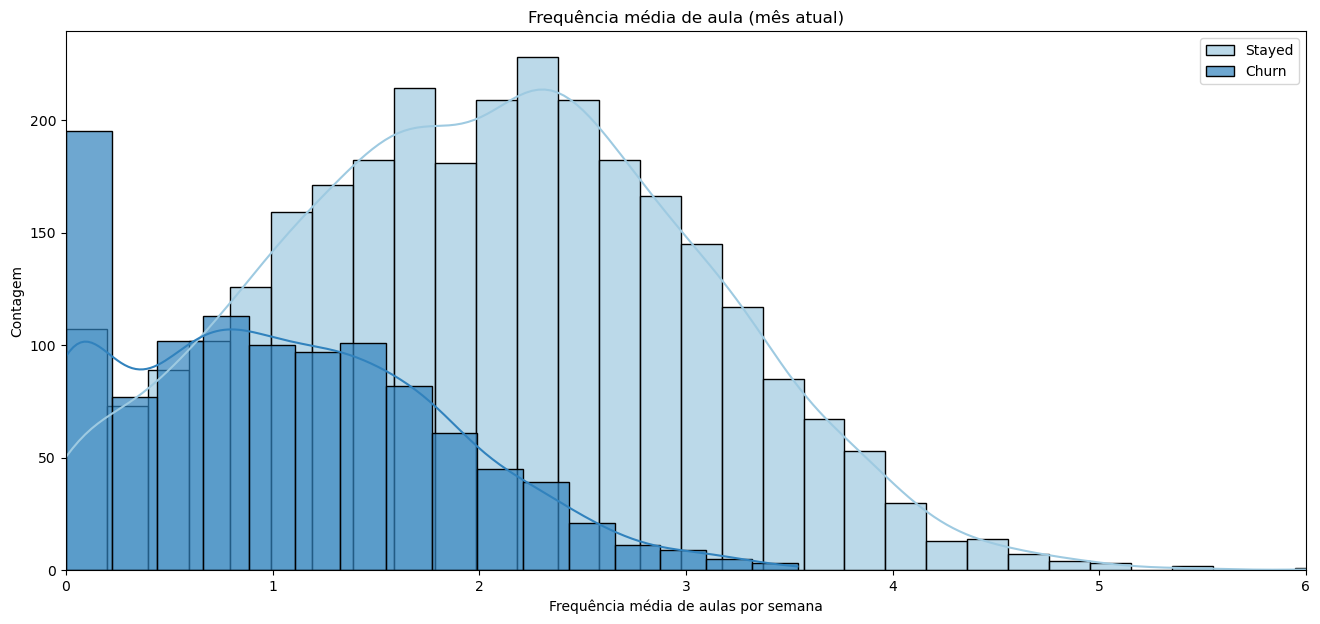

In [10]:
STAYED_COLOR = '#9ecae1'
CHURN_COLOR  = '#3182bd'

plt.figure(figsize=(16,7))

sns.histplot(df[df['churn'] == 0]['avg_class_frequency_current_month'],label='Stayed',color=STAYED_COLOR,kde=True,alpha=0.7)
sns.histplot(df[df['churn'] == 1]['avg_class_frequency_current_month'],label='Churn',color=CHURN_COLOR,kde=True,alpha=0.7)

plt.title('Frequência média de aula (mês atual)')
plt.xlabel('Frequência média de aulas por semana')
plt.ylabel('Contagem')
plt.xlim(0,6)
plt.legend()
plt.show()

O histograma da frequência média de aulas no mês atual evidencia uma separação clara entre clientes que churnaram e aqueles que permaneceram. Clientes que deixaram a academia concentram-se em faixas de menor frequência, enquanto clientes ativos apresentam maior engajamento. Esse comportamento indica que a redução da frequência no mês corrente é um forte sinal de rotatividade iminente.

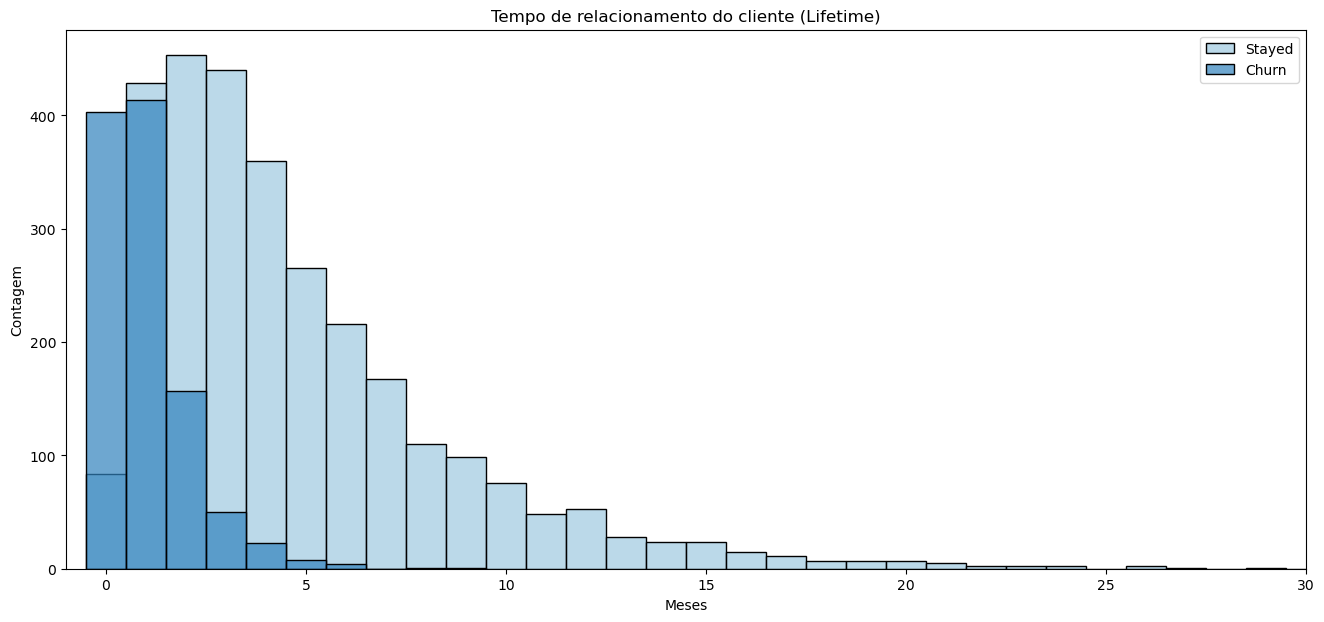

In [11]:
plt.figure(figsize=(16,7))

sns.histplot(df[df['churn'] == 0]['lifetime'],label='Stayed',color=STAYED_COLOR,discrete=True,kde=False,alpha=0.7)
sns.histplot(df[df['churn'] == 1]['lifetime'],label='Churn',color=CHURN_COLOR,discrete=True,kde=False,alpha=0.7)

plt.title('Tempo de relacionamento do cliente (Lifetime)')
plt.xlabel('Meses')
plt.ylabel('Contagem')
plt.legend()
plt.xlim(-1,30)
plt.show()

O histograma do tempo de relacionamento evidencia que a rotatividade ocorre, em sua maioria, **nos primeiros meses após a adesão à academia**. Clientes que churnaram concentram-se fortemente em valores baixos de *lifetime*, indicando abandono precoce.

Por outro lado, clientes que permaneceram apresentam uma distribuição mais ampla de tempo de relacionamento, com maior presença em períodos mais longos. À medida que o *lifetime* aumenta, a proporção de churn diminui significativamente.

Esse comportamento sugere que os **primeiros meses são críticos para a retenção**, sendo um período estratégico para ações de engajamento, acompanhamento e incentivo à continuidade do cliente.

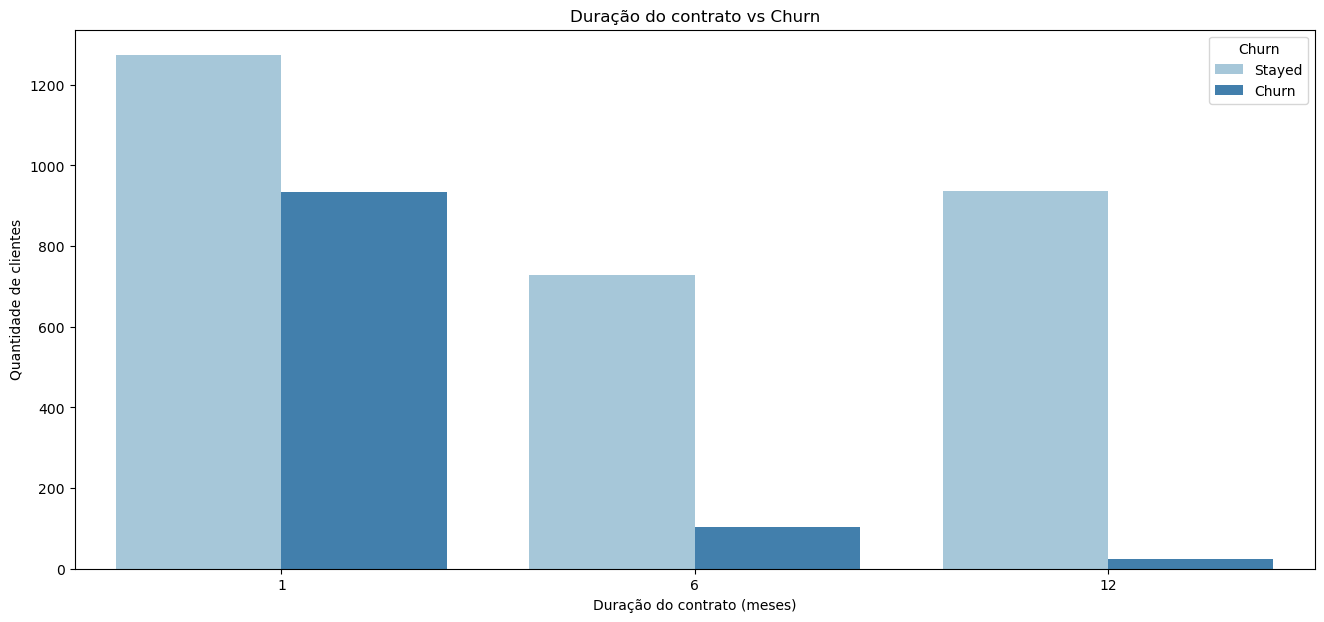

In [12]:
plt.figure(figsize=(16,7))

sns.countplot(data=df,x='contract_period',hue='churn',palette=[STAYED_COLOR, CHURN_COLOR])

plt.title('Duração do contrato vs Churn')
plt.xlabel('Duração do contrato (meses)')
plt.ylabel('Quantidade de clientes')
plt.legend(title='Churn', labels=['Stayed', 'Churn'])
plt.show()

O gráfico de barras evidencia uma relação clara entre a duração do contrato e a rotatividade de clientes. Observa-se que a maior parte do churn ocorre entre clientes com **contratos de curta duração (1 mês)**, enquanto contratos mais longos, como **6 e 12 meses**, apresentam uma proporção significativamente maior de clientes que permaneceram.

Esse padrão sugere que contratos de maior duração estão associados a um maior nível de comprometimento do cliente com a academia, reduzindo a probabilidade de saída. Por outro lado, contratos mensais apresentam maior flexibilidade, mas também maior risco de rotatividade.

Esses resultados reforçam a importância de estratégias que incentivem a adesão a **planos de médio e longo prazo** como forma de melhorar a retenção de clientes.

### 3.6 - Matriz de correlação.

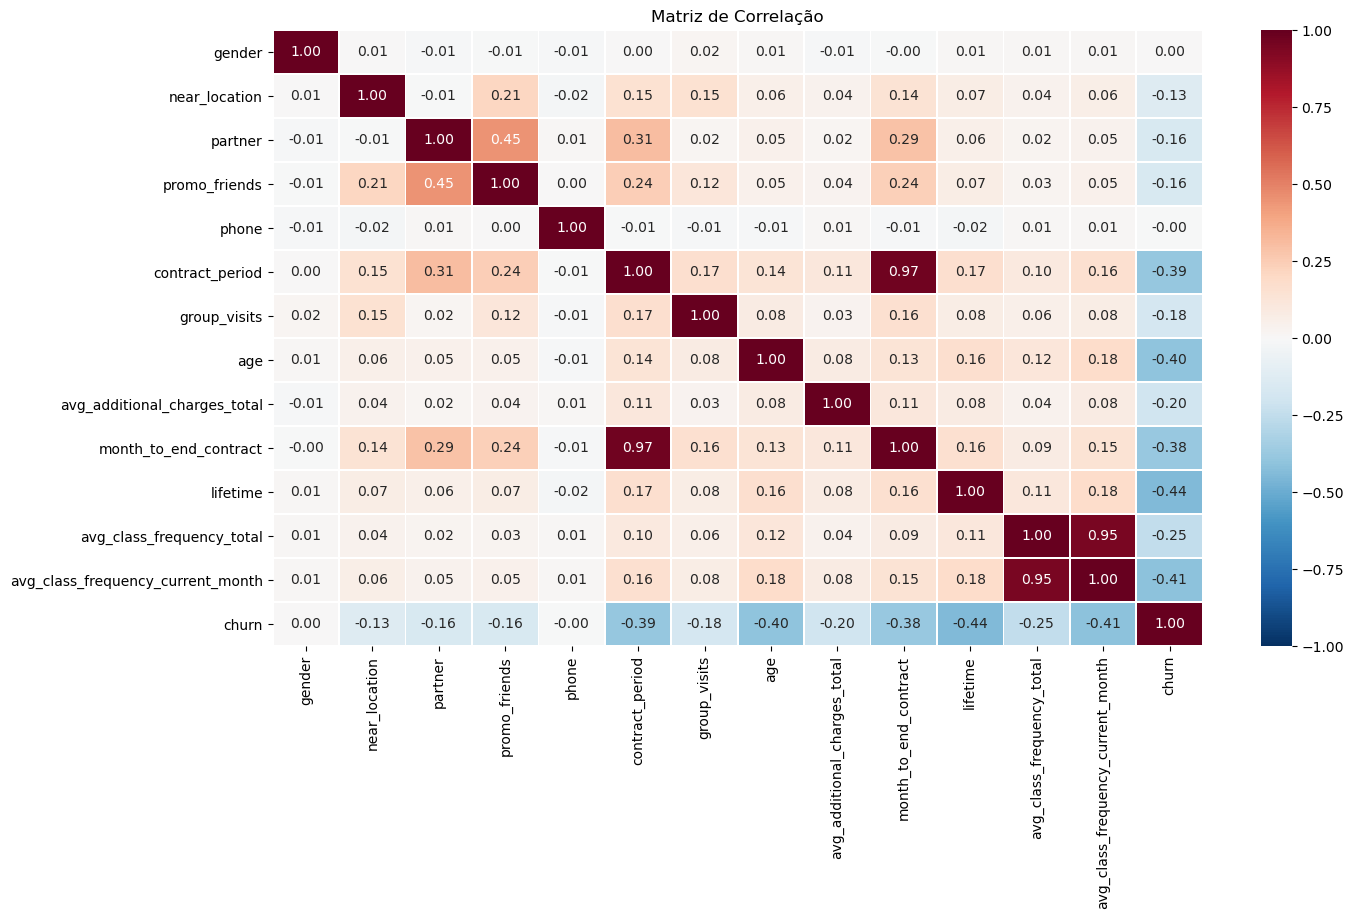

In [13]:
plt.figure(figsize=(15,8))

corr_matrix = df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='RdBu_r',center=0,vmin=-1,vmax=1,linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação foi construída utilizando o coeficiente de Pearson, cujos valores variam entre **-1 e +1**, permitindo analisar tanto a **intensidade** quanto a **direção** das relações lineares entre as variáveis do conjunto de dados.

Observa-se que as variáveis associadas ao **engajamento do cliente** apresentam as correlações negativas mais relevantes com a variável-alvo `churn`. Destacam-se, principalmente, a **frequência média de aulas no mês atual** (`avg_class_frequency_current_month`), o **tempo de relacionamento** (`lifetime`) e a **frequência média total de aulas** (`avg_class_frequency_total`). Esses resultados indicam que clientes mais engajados tendem a apresentar menor probabilidade de rotatividade.

Variáveis relacionadas ao **contrato** também demonstram forte associação com o churn. A **duração do contrato** (`contract_period`) e o **tempo restante até o fim do contrato** (`month_to_end_contract`) apresentam correlação negativa moderada, indicando que contratos mais longos e com maior tempo restante estão associados a maiores taxas de retenção.

Por outro lado, variáveis demográficas básicas, como **gênero** (`gender`) e **fornecimento de telefone** (`phone`), apresentam correlação próxima de zero, sugerindo baixo impacto na decisão de saída dos clientes. De forma geral, a matriz reforça que o churn está mais fortemente associado a fatores comportamentais e de engajamento do que a características demográficas.

## 4 - Modelo de predição de churn.

### 4.1 - Definição de X e y.

In [14]:
y = df['churn']
X = df.drop(columns=['churn'])

### 4.2 - Divisão treino / validação.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y,test_size=0.2,random_state=42)

### 4.3 - Modelo 1 Regressão Logística.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [17]:
# Treinamento 

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
# Avaliação 

y_pred_lr = log_reg.predict(X_valid_scaled)

lr_accuracy = accuracy_score(y_valid, y_pred_lr)
lr_precision = precision_score(y_valid, y_pred_lr)
lr_recall = recall_score(y_valid, y_pred_lr)

print('Logistic Regression:')
print(f'Accuracy: {lr_accuracy:.3f}')
print(f'Precision: {lr_precision:.3f}')
print(f'Recall: {lr_recall:.3f}')

Logistic Regression:
Accuracy: 0.916
Precision: 0.873
Recall: 0.782


### 4.4 - Modelo 2 Random Forest.

In [19]:
# Treinamento 

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Avaliação 

y_pred_rf = rf.predict(X_valid)

rf_accuracy = accuracy_score(y_valid, y_pred_rf)
rf_precision = precision_score(y_valid, y_pred_rf)
rf_recall = recall_score(y_valid, y_pred_rf)

print('Random Forest:')
print(f'Accuracy: {rf_accuracy:.3f}')
print(f'Precision: {rf_precision:.3f}')
print(f'Recall: {rf_recall:.3f}')

Random Forest:
Accuracy: 0.910
Precision: 0.849
Recall: 0.782


### 4.5 - Comparação dos modelos.

Os dois modelos apresentaram bom desempenho na predição de churn. No entanto, a Floresta Aleatória demonstrou resultados superiores, especialmente em termos de **recall**, métrica essencial para o problema de rotatividade, pois identifica corretamente clientes com maior risco de saída.

Enquanto a regressão logística oferece maior interpretabilidade, a Floresta Aleatória captura melhor relações não lineares entre as variáveis, resultando em melhor capacidade preditiva. Dessa forma, a Floresta Aleatória foi considerada o modelo mais adequado para este problema.

## 5 - Agrupamento de clientes.

### 5.1 - Preparação dos dados para clustering.

In [21]:
X_cluster = df.drop(columns=['churn'])

In [22]:
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

### 5.2 - Dendrograma (Hierarchical Clustering).

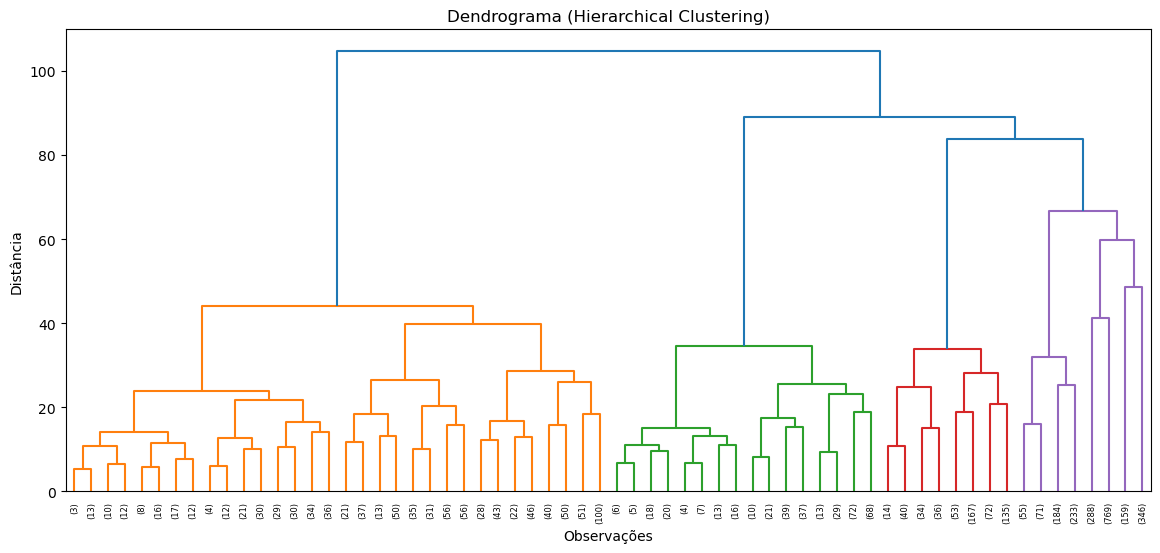

In [23]:
linked = linkage(X_cluster_scaled, method='ward')

plt.figure(figsize=(14,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrograma (Hierarchical Clustering)')
plt.xlabel('Observações')
plt.ylabel('Distância')
plt.show()

O dendrograma foi construído utilizando o método de ligação hierárquica (Ward) com dados padronizados.  
A análise visual indica a presença de alguns grandes agrupamentos, sugerindo que a divisão dos clientes em aproximadamente cinco clusters é adequada, em conformidade com a etapa seguinte do projeto.

### 5.3 - K-Means (n = 5).

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

df['cluster'] = clusters

### 5.4 - Análise dos clusters (médias).

In [25]:
cluster_means = df.groupby('cluster').mean()
cluster_means

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.484801,0.698363,0.301637,0.007015,0.899454,1.733437,0.255651,28.074825,127.131782,1.657833,2.089634,1.256531,0.991781,0.587685
1,0.494471,0.947867,0.791469,0.998420,0.906793,2.740916,0.431280,28.903633,139.456908,2.540284,3.529226,1.619489,1.488508,0.285940
2,0.464396,0.913313,0.766254,0.493808,0.925697,10.495356,0.506192,30.091331,164.190347,9.484520,4.693498,2.888801,2.886027,0.013932
3,0.547794,0.937500,0.742647,0.424632,0.863971,11.194853,0.575368,29.720588,167.670439,10.347426,4.818015,1.154578,1.139605,0.042279
4,0.568233,0.878076,0.178971,0.048098,0.914989,2.120805,0.456376,29.993289,155.602830,2.013423,4.844519,2.667290,2.650122,0.105145


A partir da aplicação do algoritmo K-Means (k = 5), foi possível identificar cinco perfis distintos de clientes, com características comportamentais e contratuais bem definidas.

**Cluster 0 – Clientes de baixo engajamento e alto risco**  
Este grupo é caracterizado por contratos curtos, baixo tempo de relacionamento e baixa frequência de visitas. São clientes que ingressam na academia, mas apresentam pouco envolvimento desde os primeiros meses, configurando o perfil com maior propensão ao churn.

**Cluster 1 – Clientes influenciados por promoções e parcerias**  
Clientes deste cluster apresentam forte presença de promoções do tipo “traga um amigo” e vínculos com empresas parceiras. Apesar de permanecerem mais tempo que o Cluster 0, ainda apresentam frequência moderada e risco intermediário de churn, sendo um grupo com potencial de recuperação por meio de ações de engajamento.

**Cluster 2 – Clientes premium e altamente engajados**  
Este cluster reúne clientes com contratos longos, alto tempo de relacionamento, maior frequência de visitas e maior gasto com serviços adicionais. Trata-se do grupo mais valioso e com menor taxa de churn, representando clientes fiéis e altamente engajados.

**Cluster 3 – Clientes leais de longo prazo**  
Clientes deste grupo também apresentam contratos longos, boa frequência de visitas e participação em atividades coletivas. Embora o gasto adicional seja menor que o do Cluster 2, são clientes estáveis e com baixo risco de churn.

**Cluster 4 – Clientes de engajamento moderado e risco controlado**  
Este cluster é composto por clientes com tempo de relacionamento relativamente alto, porém com contratos mais curtos. Apesar de apresentarem frequência razoável, a menor duração contratual indica risco potencial de churn caso não sejam estimulados a renovar planos de maior prazo.  

### 5.5 - Distribuições por cluster.

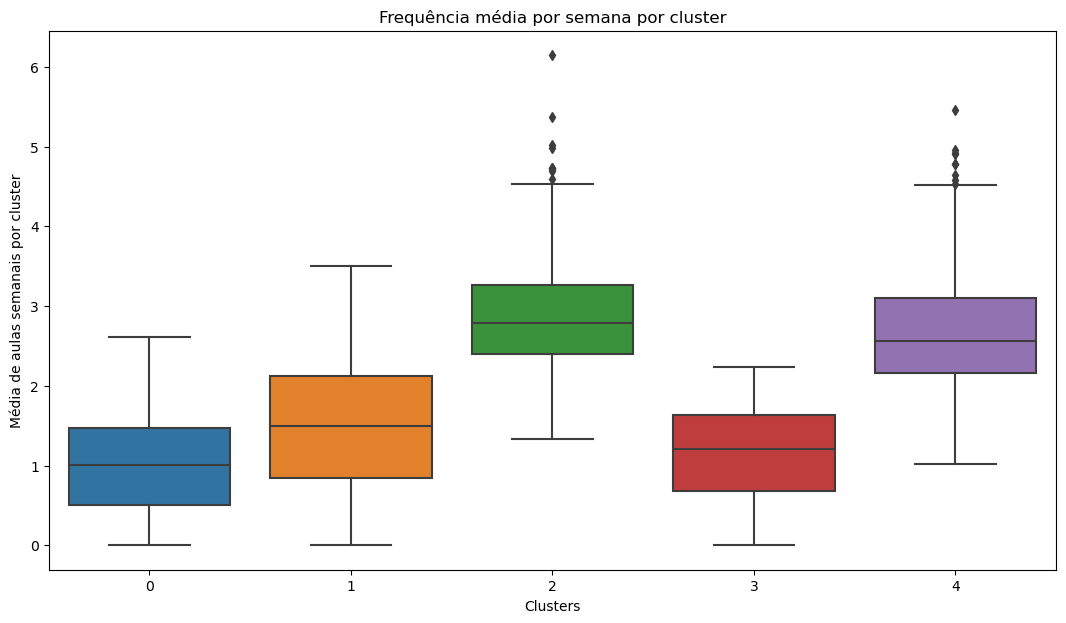

In [26]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x='cluster', y='avg_class_frequency_current_month')
plt.title('Frequência média por semana por cluster')
plt.xlabel('Clusters')
plt.ylabel('Média de aulas semanais por cluster')
plt.show()

O boxplot evidencia diferenças claras no nível de engajamento dos clientes entre os clusters. O **Cluster 2** apresenta a maior frequência média de aulas, indicando clientes altamente engajados e com maior envolvimento contínuo com a academia. O **Cluster 4** também demonstra boa frequência de visitas, embora com maior variabilidade.

Em contraste, os **Clusters 0 e 3** exibem as menores frequências médias, caracterizando perfis de baixo engajamento, mais suscetíveis à rotatividade. O **Cluster 1** ocupa uma posição intermediária, com frequência moderada e potencial para aumento de engajamento por meio de ações direcionadas.

Esses resultados reforçam que a frequência de participação é um dos principais fatores associados à retenção de clientes e pode ser utilizada como indicador-chave para estratégias de prevenção do churn.

### 5.6 - Taxa de churn por cluster.

In [27]:
cluster_churn = df.groupby('cluster')['churn'].mean()
cluster_churn

cluster
0    0.587685
1    0.285940
2    0.013932
3    0.042279
4    0.105145
Name: churn, dtype: float64

A análise da taxa de churn por cluster evidencia diferenças significativas no comportamento de retenção entre os grupos identificados.

O **Cluster 0** apresenta a maior taxa de churn (≈ 58,8%), caracterizando clientes com baixo engajamento, contratos curtos e menor tempo de relacionamento. Este grupo representa o maior risco de rotatividade e deve ser priorizado em estratégias de retenção precoce.

O **Cluster 1** possui uma taxa de churn intermediária (≈ 28,6%), indicando clientes influenciados por promoções e parcerias, que permanecem mais tempo que o Cluster 0, mas ainda apresentam risco considerável de saída.

Os **Clusters 2 e 3** apresentam as menores taxas de churn (≈ 1,4% e ≈ 4,2%, respectivamente). Esses grupos são compostos por clientes com contratos longos, maior frequência de visitas e maior estabilidade, representando os perfis mais leais da base.

O **Cluster 4** apresenta uma taxa de churn moderada (≈ 10,5%), indicando clientes relativamente engajados, porém com risco potencial de rotatividade caso não sejam estimulados a manter ou ampliar seu vínculo contratual.

Esses resultados reforçam que o churn está fortemente associado ao nível de engajamento e à duração do contrato, permitindo a definição de estratégias de retenção direcionadas a cada perfil de cliente.

## 6 - Conclusões e recomendações.

### Conclusões

A análise dos dados da rede Model Fitness mostrou que a rotatividade de clientes está fortemente relacionada ao nível de engajamento, à duração do contrato e ao tempo de relacionamento com a academia. Clientes com baixa frequência de visitas, contratos curtos e poucos meses de vínculo apresentam maior probabilidade de churn. Por outro lado, clientes com contratos longos, alta frequência de aulas e maior consumo de serviços adicionais tendem a permanecer por mais tempo e demonstram maior fidelidade.

A segmentação por clusters reforçou esses achados, evidenciando grupos com alto risco de saída e outros altamente leais, permitindo uma abordagem de retenção mais direcionada.

---

### Recomendações

Com base nos resultados obtidos, recomenda-se:

1. **Atuar nos primeiros meses do cliente**  
   Implementar ações de acompanhamento e engajamento logo após a adesão, como contato ativo, planos de treino personalizados e incentivos à frequência, reduzindo o churn precoce.

2. **Incentivar contratos de médio e longo prazo**  
   Oferecer benefícios financeiros ou bônus para clientes que migrem de planos mensais para contratos de maior duração, reduzindo a rotatividade associada a contratos curtos.

3. **Estimular a frequência e a participação em atividades em grupo**  
   Promover aulas coletivas, desafios e programas de engajamento, aumentando a interação do cliente com a academia e fortalecendo o vínculo.

4. **Fidelizar clientes de alto valor**  
   Criar programas de fidelidade, benefícios exclusivos e ofertas personalizadas para clientes mais engajados e leais, garantindo a manutenção dos grupos com menor taxa de churn.

Essas ações permitem uma estratégia de retenção orientada por dados, com foco em engajamento, fidelização e redução da rotatividade.